# 版本2 增加区域插值功能

JAX Devices: [cuda(id=0)]
Torch Devices: 1
Loading model from /nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/pkl/neuralgcm_04_30_2024_neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl...
Model levels (37): [   1    2    3    5    7   10   20   30   50   70  100  125  150  175
  200  225  250  300  350  400  450  500  550  600  650  700  750  775
  800  825  850  875  900  925  950  975 1000]
Model Grid: Lat 128, Lon 256
Compiling JAX functions (Fused)...
Functions compiled.
Warming up and detecting output keys...
Warmup complete.
Reading datasets...
region_lon_grid的形状为 (281, 241)
region_lat_grid的形状为 (281, 241)
Target Levels: [50, 500, 850, 1000]
Preparing inputs for 3 datasets...


2025-12-09 13:53:52.158331: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.5 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Data Prep Time: 11.7376s
Expected grid shape (Lon, Lat): (256, 128)
Provided grid shape: (281, 241)
请确保使用: meshgrid(lon, lat, indexing='ij') 来创建网格
Computing interpolation indices for region shape (281, 241)...
DEBUG: Source grid sizes -> Lon: 256, Lat: 128
DEBUG: Target grid shape -> (281, 241)
DEBUG: Max deviation from integer indices -> Lat: 0.500000, Lon: 0.000000
DEBUG: Snapped to integer -> Lat: 65754/67721, Lon: 67721/67721
DEBUG: Output indices shape -> (2, 281, 241)
DEBUG: Lon indices range -> [256.00, 256.00]
DEBUG: Lat indices range -> [63.50, 127.00]
Running Fused Inference (Encode->Unroll->Stack->Interpolate)...
True Inference Time (GPU): 66.3698s
Inference done. Converting DLPack to Torch...
Conversion Time: 1.0293s
Total Forward Time: 79.1367s

Output Shapes:
NeuralGCM Pred: torch.Size([3, 20, 281, 241, 24])
Physics Core:   torch.Size([3, 20, 281, 241, 24])
ERA5 Target:    torch.Size([3, 20, 281, 241, 24])
Tensor Device: cuda:0
Plotting RMSE Grid: 5 Rows (Vars) x 4 Cols (

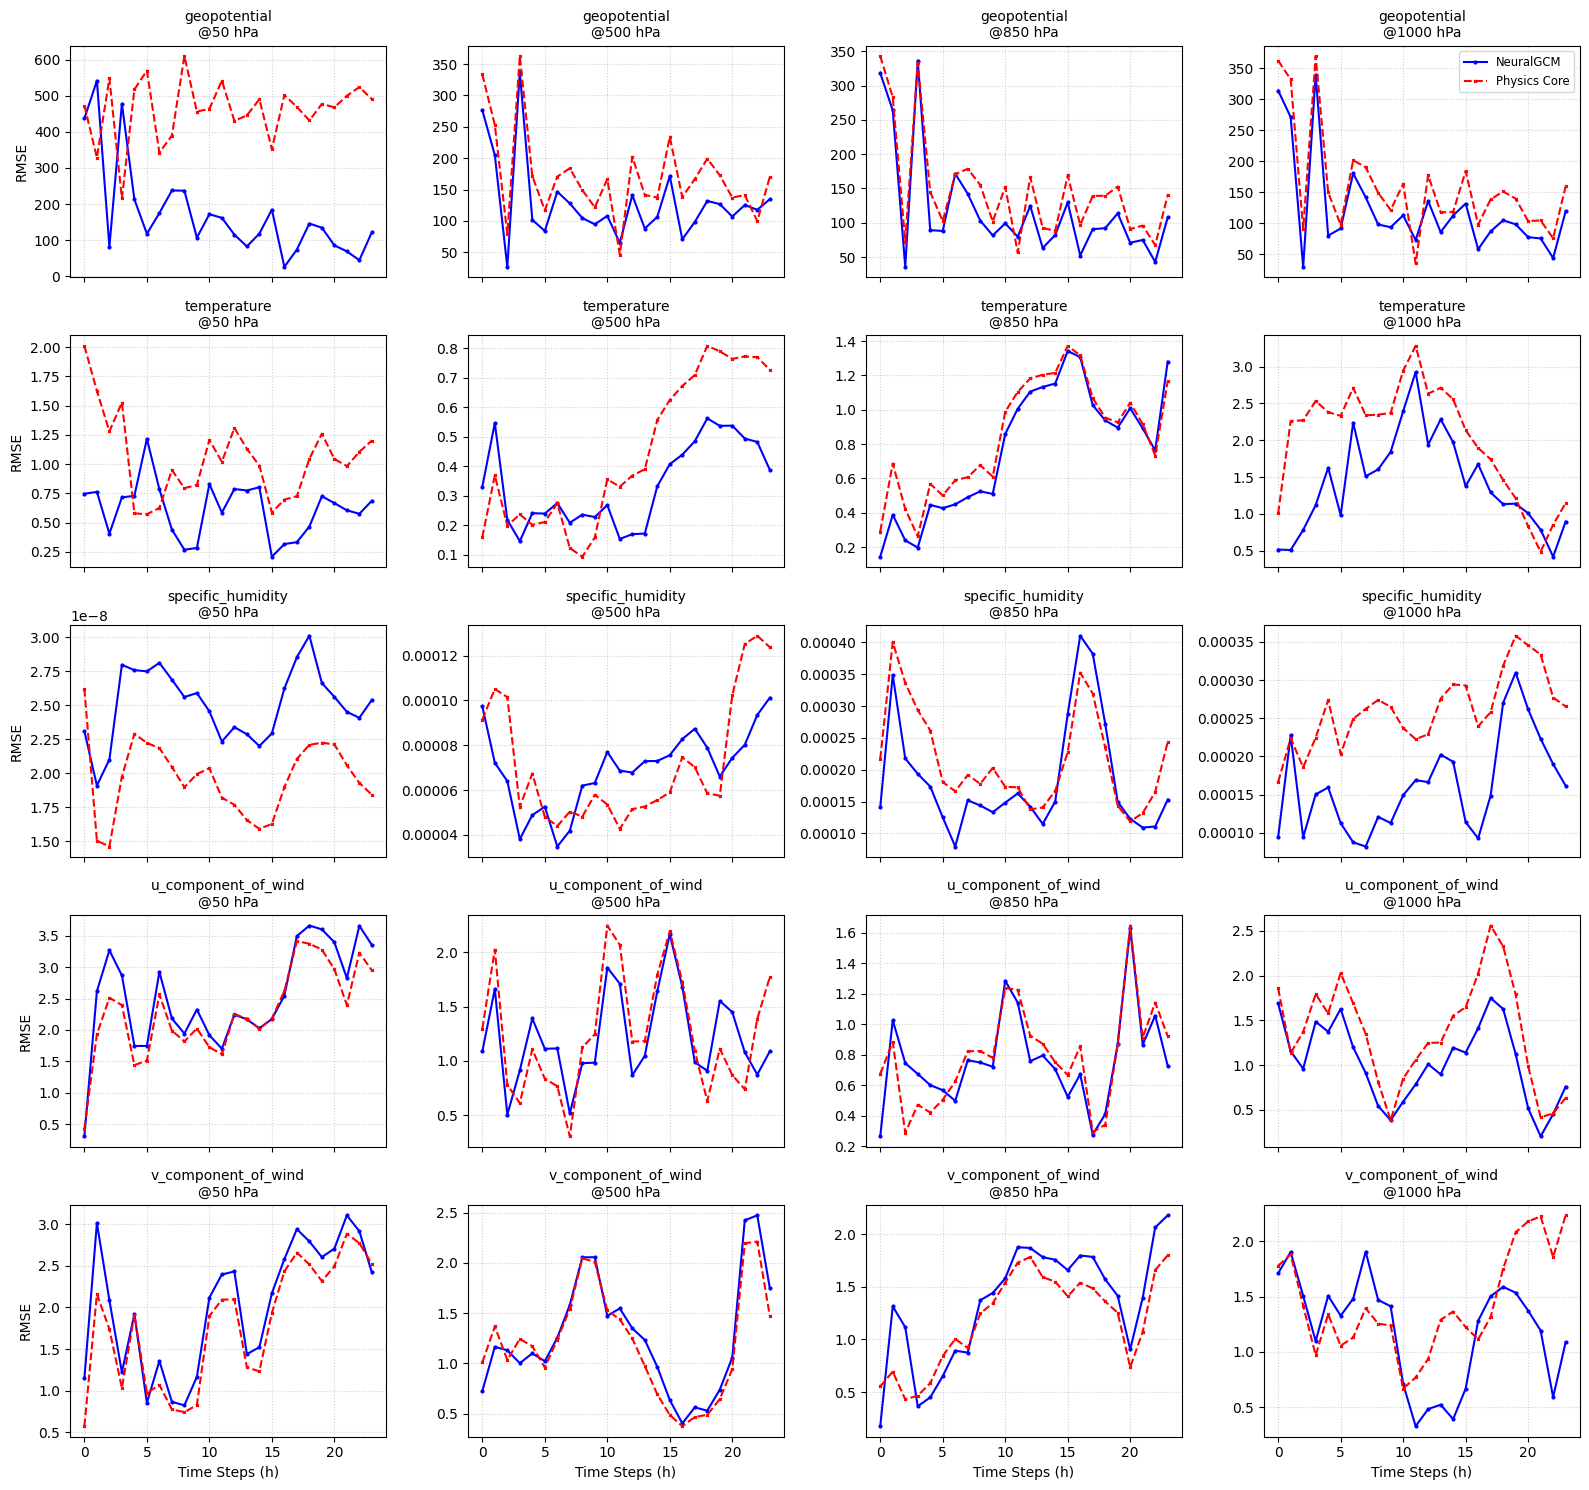

In [ ]:
# %% %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%neW%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1,2'
device_ids = [0,1]
    
import gcsfs
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import xarray
import neuralgcm
import pandas as pd
import matplotlib.pyplot as plt
import torch  # 新增 torch 导入
from jax import dlpack as jax_dlpack
from torch.utils import dlpack as torch_dlpack
import time # 用于计时
from jax.scipy.ndimage import map_coordinates # 用于高效插值

# 确保 JAX 使用 GPU
print(f"JAX Devices: {jax.devices()}")
print(f"Torch Devices: {torch.cuda.device_count()}")
gcs = gcsfs.GCSFileSystem(token='anon')

# %%
# 辅助函数: 堆叠和拆分字典列表
def stack_dicts(dicts_list):
    """Stacks a list of dictionaries into a single dictionary with a batch dimension."""
    # jnp.stack automatically moves data to the default device (GPU if available)
    return jax.tree_util.tree_map(lambda *args: jnp.stack(args), *dicts_list)

def unstack_dicts(batched_dict, batch_size):
    """Splits a batched dictionary back into a list of dictionaries."""
    return [
        jax.tree_util.tree_map(lambda x: x[i], batched_dict)
        for i in range(batch_size)
    ]

# %%
# 核心堆叠函数 (普通 JAX 函数，将被集成到 JIT 块中)
def _core_stack_and_transpose(data_dict, level_indices, interp_indices=None):
    """
    Core stacking logic to be used INSIDE a JIT function.
    
    Args:
        data_dict: Dictionary of JAX arrays (Batch, Time, Level, Lat, Lon)
        level_indices: Array of indices to select from Level dimension
        interp_indices: Tuple (lat_indices, lon_indices) for interpolation. 
                        If provided, interpolates to these points.
                        Each is (Target_H, Target_W) or similar flat.
                        Using map_coordinates logic.
    """
    
    # 硬编码变量列表，确保 JIT 稳定性
    # 如果模型变量名改变，这里需要同步修改
    # 恢复为只包含基础变量 (5个)，去除云变量，以恢复20个通道的输出 (5变量 * 4层)
    multi_level_vars = ['geopotential', 'temperature', 'specific_humidity', 'u_component_of_wind', 'v_component_of_wind']
    # 如果后续需要云变量，可以取消注释：
    # multi_level_vars += ['specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']
    
    # Single-level vars: 
    possible_single_vars = [
        '2m_temperature', 
        '10m_u_component_of_wind', 
        '10m_v_component_of_wind', 
        'mean_sea_level_pressure',
        'sea_surface_temperature', 
        'sea_ice_cover'
    ]
    
    # 插值辅助函数
    def apply_interpolation(tensor_data):
        """
        tensor_data: (Batch, Time, Dim0, Dim1) - 实际上是 (Batch, Time, Lon, Lat) = (B, T, 256, 128)
        interp_indices: (2, H_new, W_new) - [lon_indices, lat_indices]
                        其中 lon_indices 对应数据的第一个空间维度 (Lon)
                        lat_indices 对应数据的第二个空间维度 (Lat)
        Returns: (Batch, Time, H_new, W_new)
        
        关键修复: 
        1. 正确处理数据的实际维度顺序 (Lon, Lat) 而非假设的 (Lat, Lon)
        2. 分别处理纬度和经度的边界模式
        - 经度 (dim0): 使用 wrap/mod 模式，因为经度是周期性的 (0 到 360)
        - 纬度 (dim1): 使用 clip 模式，因为纬度不是周期性的 (-90 到 90)
        """
        if interp_indices is None:
            return tensor_data
            
        B, T, H, W = tensor_data.shape  # H=Lon维度大小(256), W=Lat维度大小(128)
        reshaped = tensor_data.reshape(B * T, H, W)
        
        # interp_indices 形状: (2, H_new, W_new)
        # [0]: lon_indices (对应数据的第一个空间维度, 索引范围 [0, 256))
        # [1]: lat_indices (对应数据的第二个空间维度, 索引范围 [0, 128))
        lon_indices = interp_indices[0]  # (H_new, W_new)
        lat_indices = interp_indices[1]  # (H_new, W_new)
        data_lon_size = H  # 256
        data_lat_size = W  # 128
        
        # 关键修复: 
        # - 经度 (dim0): 使用 wrap 模式处理周期性边界
        # - 纬度 (dim1): 使用 clip 模式，防止跨越极地边界
        lon_indices_wrapped = lon_indices % data_lon_size
        lat_indices_clipped = jnp.clip(lat_indices, 0.0, data_lat_size - 1.0)
        
        # 重新组合索引: [dim0_idx, dim1_idx] = [lon, lat] 匹配数据的 (Lon, Lat) 顺序
        fixed_indices = jnp.stack([lon_indices_wrapped, lat_indices_clipped], axis=0)
        
        # vmap over the batch dimension (Batch*Time)
        # map_coordinates(input, coordinates, order=1) -> input is (H, W), coords is (2, H_new, W_new)
        # output is (H_new, W_new)
        
        # 定义单张图的插值函数
        # order=1: 双线性插值
        # mode='wrap': 对于已经处理过的索引是安全的
        def interp_single(img):
            return map_coordinates(img, fixed_indices, order=1, mode='wrap')
            
        interp_out = jax.vmap(interp_single)(reshaped)
        
        # Reshape back to (Batch, Time, H_new, W_new)
        new_H, new_W = interp_indices.shape[1], interp_indices.shape[2]
        return interp_out.reshape(B, T, new_H, new_W)


    # Helper to extract and stack one set of vars
    def process_subset(prefix=''):
        channels = []
        
        # 1. Process Multi-level
        multi_arrays = []
        for v in multi_level_vars:
            key = prefix + v
            # JIT time check: key existence is static
            if key in data_dict:
                multi_arrays.append(data_dict[key])
        
        if multi_arrays:
            # Stack Vars
            stacked = jnp.stack(multi_arrays, axis=0) # (Vars, Batch, Time, Level, Lat, Lon)
            
            # Select Levels
            selected = stacked[:, :, :, level_indices, :, :] # (Vars, Batch, Time, SelLevels, Lat, Lon)
            
            # Move Level to Channel dim (dim 1) -> (Vars, SelLevels, Batch, Time, Lat, Lon)
            # We want final output: (Batch, Channel, Lat, Lon, Time)
            # Intermediate here: flatten Vars*Levels
            
            # Transpose to prepare for flatten: (Batch, Time, Lat, Lon, Vars, SelLevels) -> Wait, interpolation needs Lat/Lon last usually for convenience?
            # actually our apply_interpolation takes (Batch, Time, Lat, Lon)
            
            # Let's rearrange to: (Vars, SelLevels, Batch, Time, Lat, Lon)
            # Flatten first two: (Channels, Batch, Time, Lat, Lon)
            V, B, T, L, H, W = selected.shape
            
            # Transpose to (Vars, SelLevels, Batch, Time, Lat, Lon) -> already is, basically? No, shape is (V, B, T, L, H, W)
            # We want (V*L, B, T, H, W)
            permuted = jnp.transpose(selected, (0, 3, 1, 2, 4, 5)) # (Var, Level, Batch, Time, Lat, Lon)
            flat = permuted.reshape(-1, B, T, H, W) # (Channels, Batch, Time, Lat, Lon)
            
            # Now we have a list of channels where each is (Batch, Time, Lat, Lon)
            # We can apply interpolation to the whole block if we treat Channels as another batch dim
            # Or just loop/stack.
            # Let's stack into one big tensor: (Channels, Batch, Time, Lat, Lon)
            # Then reshape to (Channels*Batch*Time, Lat, Lon) for interpolation?
            # Or just use vmap.
            
            channels_list = []
            for i in range(flat.shape[0]):
                c_data = flat[i] # (Batch, Time, Lat, Lon)
                if interp_indices is not None:
                    c_data = apply_interpolation(c_data)
                channels_list.append(c_data)
            
            # Stack back: (Channels, Batch, Time, H_new, W_new)
            processed_multi = jnp.stack(channels_list, axis=0)
            channels.append(processed_multi)
            
        # 2. Process Single-level
        single_arrays = []
        for v in possible_single_vars:
            key = prefix + v
            if key in data_dict:
                arr = data_dict[key]
                # Handle possible dimensions
                # Sometimes single level vars have a singleton level dim (Batch, Time, 1, Lat, Lon)
                if arr.ndim == 5 and arr.shape[2] == 1: 
                    arr = arr.squeeze(axis=2)
                
                # Ensure it's (Batch, Time, Lat, Lon)
                if arr.ndim == 4:
                    single_arrays.append(arr)
        
        if single_arrays:
            # Stack along new dim -> (Vars, Batch, Time, Lat, Lon)
            stacked_single = jnp.stack(single_arrays, axis=0)
            
            # Apply interpolation
            single_processed_list = []
            for i in range(stacked_single.shape[0]):
                c_data = stacked_single[i]
                if interp_indices is not None:
                    c_data = apply_interpolation(c_data)
                single_processed_list.append(c_data)
                
            processed_single = jnp.stack(single_processed_list, axis=0)
            channels.append(processed_single)
            
        if not channels:
            return None
            
        # Concatenate all (Multi + Single)
        # Shape: (TotalCh, Batch, Time, H_new, W_new)
        final_stack = jnp.concatenate(channels, axis=0) 
        
        # Transpose to (Batch, TotalCh, H_new, W_new, Time)
        # Note: If no interpolation, H_new=Lat, W_new=Lon.
        # But wait, original output without interp was (Batch, TotalCh, Lat, Lon, Time) which is (128, 256).
        # map_coordinates output H_new corresponds to indices.shape[1], W_new to indices.shape[2].
        # In usage: indices from meshgrid(Lat, Lon) -> H_new=Lat_dim, W_new=Lon_dim.
        # So output is consistently (Batch, Channels, Lat, Lon, Time).
        return jnp.transpose(final_stack, (1, 0, 3, 4, 2)) 

    # Process Full
    tensor_full = process_subset(prefix='')
    
    # Process Physics Core (prefix '_physics_')
    tensor_phy = process_subset(prefix='_physics_')
    
    return tensor_full, tensor_phy


class NeuralGCMInference:
    def __init__(self, checkpoint_path, inner_steps=1, outer_steps=24):
        """
        初始化 NeuralGCM 推理对象.
        """
        self.inner_steps = inner_steps
        self.outer_steps = outer_steps
        self.timedelta = np.timedelta64(1, 'h') * inner_steps
        self.times = (np.arange(outer_steps) * inner_steps)
        
        print(f"Loading model from {checkpoint_path}...")
        with open(checkpoint_path, 'rb') as f:
            ckpt = pickle.load(f)
            
        self.model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
        self.model_with_physics = self.model.with_physics_core_output(enable=True)
        
        # 获取所有气压层数值
        self.all_levels = self.model.data_coords.vertical.centers
        print(f"Model levels ({len(self.all_levels)}): {self.all_levels}")
        
        # 获取模型原始网格信息 (用于计算插值索引)
        self.model_lat = self.model.data_coords.horizontal.latitudes
        self.model_lon = self.model.data_coords.horizontal.longitudes
        print(f"Model Grid: Lat {len(self.model_lat)}, Lon {len(self.model_lon)}")
        
        # 编译 JAX 函数
        print("Compiling JAX functions (Fused)...")
        self._compile_fused_functions()
        print("Functions compiled.")
        
        # 预热 & 探测 Keys
        print("Warming up and detecting output keys...")
        self._warmup_and_debug_keys()
        print("Warmup complete.")

    def _compile_fused_functions(self):
        """
        编译融合了 Encode + Unroll + Stack 的超大 JIT 函数。
        """
        
        # 1. 基础 unroll wrapper
        def unroll_op(state, forcings):
            return self.model_with_physics.unroll(
                state,
                forcings,
                steps=self.outer_steps,
                timedelta=self.timedelta,
                start_with_input=True
            )
        
        # 2. 融合函数
        # 增加 interp_indices 参数
        def forward_and_stack(inputs, input_forcings, rng_keys, all_forcings, level_indices, interp_indices):
            initial_state = jax.vmap(self.model.encode)(inputs, input_forcings, rng_keys)
            _, predictions_dict = jax.vmap(unroll_op)(initial_state, all_forcings)
            
            t_full, t_phy = _core_stack_and_transpose(predictions_dict, level_indices, interp_indices)
            return t_full, t_phy

        self.fused_forward_fn = jax.jit(forward_and_stack)
        
        # Target 的 stack
        def stack_target(target_dict, level_indices, interp_indices):
            t_full, _ = _core_stack_and_transpose(target_dict, level_indices, interp_indices)
            return t_full
            
        self.stack_target_fn = jax.jit(stack_target)
        
        # DEBUG Helper
        def debug_step_fn(inputs, input_forcings, rng_key, all_forcings):
            state = self.model.encode(inputs, input_forcings, rng_key)
            _, preds = self.model_with_physics.unroll(
                state, all_forcings, steps=1, timedelta=self.timedelta, start_with_input=True
            )
            return preds
        
        self._debug_step_fn = debug_step_fn

    def _prepare_batch_inputs(self, datasets_list):
        """准备批量输入数据，并确保它们被移动到 GPU."""
        inputs_list = []
        input_forcings_list = []
        all_forcings_list = []
        target_datasets = []

        print(f"Preparing inputs for {len(datasets_list)} datasets...")
        
        for i, ds in enumerate(datasets_list):
            # inputs_from_xarray 返回 numpy 数组 (CPU)
            inputs_list.append(self.model.inputs_from_xarray(ds.isel(time=0)))
            input_forcings_list.append(self.model.forcings_from_xarray(ds.isel(time=0)))
            all_forcings_list.append(self.model.forcings_from_xarray(ds.head(time=1)))
            
            target_trajectory = self.model.inputs_from_xarray(
                ds
                .thin(time=(self.inner_steps // 1)) 
                .isel(time=slice(self.outer_steps))
            )
            target_datasets.append(target_trajectory)

        # stack_dicts 使用 jnp.stack。JAX 会自动将数据移动到默认设备 (通常是 GPU 0)
        # 但为了绝对保险，我们显式 device_put
        
        batched_inputs = stack_dicts(inputs_list)
        batched_input_forcings = stack_dicts(input_forcings_list)
        batched_all_forcings = stack_dicts(all_forcings_list)
        batched_targets = stack_dicts(target_datasets)
        
        # Explicitly move to GPU (if not already)
        # 这一步会发生数据传输 (CPU -> GPU)，这是不可避免的，但只发生一次
        batched_inputs = jax.device_put(batched_inputs)
        batched_input_forcings = jax.device_put(batched_input_forcings)
        batched_all_forcings = jax.device_put(batched_all_forcings)
        batched_targets = jax.device_put(batched_targets)
        
        rng_key = jax.random.key(42)
        batched_rng_keys = jax.random.split(rng_key, len(datasets_list))
        
        return batched_inputs, batched_input_forcings, batched_all_forcings, batched_rng_keys, batched_targets

    def _warmup_and_debug_keys(self):
        """Debug Output Keys."""
        try:
            # Note: Output variable keys depend on the specific model config.
            # We skip actual warmup run to avoid messing up with different input shapes.
            pass
        except Exception as e:
            print(f"Warmup warning: {e}")

    def _compute_interp_indices(self, target_lat, target_lon):
        """
        计算目标经纬度在模型网格中的"浮点数索引"，用于后续的插值函数 map_coordinates。
        
        关键改进:
        1. 使用 float64 进行高精度计算
        2. 对于接近网格点的值，强制对齐到精确整数索引
        3. 正确处理数据的实际维度顺序: (Lon, Lat) = (256, 128)
        4. 这避免了由浮点数精度导致的微小偏差引发的插值误差
        
        Args:
            target_lat: (H_new, W_new) 目标纬度网格
            target_lon: (H_new, W_new) 目标经度网格
            
        Returns:
            indices: (2, H_new, W_new) 其中 indices[0] = lon_indices, indices[1] = lat_indices
                    这个顺序匹配数据的 (Lon, Lat) 维度顺序
        """
        # 将模型原始的经纬度转为 numpy 数组 (使用 float64 保证精度)
        src_lat = np.array(self.model_lat, dtype=np.float64)  # (128,)
        src_lon = np.array(self.model_lon, dtype=np.float64)  # (256,)
        
        print(f"DEBUG: Source grid sizes -> Lon: {len(src_lon)}, Lat: {len(src_lat)}")
        print(f"DEBUG: Target grid shape -> {target_lat.shape}")
        
        # 1. 计算纬度索引 (Lat indices) - 索引范围 [0, 127]
        lat_indices_range = np.arange(len(src_lat), dtype=np.float64)
        
        # 处理降序纬度 (90 -> -90)
        if src_lat[0] > src_lat[-1]: 
            src_lat_sorted = src_lat[::-1]
            lat_indices_sorted = lat_indices_range[::-1]
        else:
            src_lat_sorted = src_lat
            lat_indices_sorted = lat_indices_range
            
        flat_target_lat = np.array(target_lat, dtype=np.float64).ravel() 
        flat_lat_indices = np.interp(flat_target_lat, src_lat_sorted, lat_indices_sorted)
        target_lat_indices = flat_lat_indices.reshape(target_lat.shape)
        
        # 2. 计算经度索引 (Lon indices) - 索引范围 [0, 255]
        flat_target_lon = np.array(target_lon, dtype=np.float64).ravel()
        
        # 归一化目标经度到 [0, 360) 范围
        if src_lon.min() >= 0:
            flat_target_lon = flat_target_lon % 360.0
        
        # 构造 src_lon_extended 处理周期性边界
        lon_step = src_lon[1] - src_lon[0]
        src_lon_extended = np.append(src_lon, src_lon[-1] + lon_step) 
        lon_indices_extended = np.arange(len(src_lon) + 1, dtype=np.float64)
        
        target_lon_indices = np.interp(flat_target_lon, src_lon_extended, lon_indices_extended)
        target_lon_indices = target_lon_indices.reshape(target_lon.shape)
        
        # 3. 对接近整数的索引进行"吸附"处理
        SNAP_THRESHOLD = 1e-6
        
        # 纬度索引吸附
        lat_rounded = np.round(target_lat_indices)
        lat_diff = np.abs(target_lat_indices - lat_rounded)
        snap_mask_lat = lat_diff < SNAP_THRESHOLD
        target_lat_indices = np.where(snap_mask_lat, lat_rounded, target_lat_indices)
        
        # 经度索引吸附
        lon_rounded = np.round(target_lon_indices)
        lon_diff = np.abs(target_lon_indices - lon_rounded)
        snap_mask_lon = lon_diff < SNAP_THRESHOLD
        target_lon_indices = np.where(snap_mask_lon, lon_rounded, target_lon_indices)
        
        # 4. 堆叠结果
        # 关键: 数据的维度顺序是 (Lon, Lat) = (256, 128)
        # 所以 map_coordinates 的索引顺序必须是 [lon_index, lat_index]
        # coordinate_0 对应数据的第一个空间维度 (Lon)
        # coordinate_1 对应数据的第二个空间维度 (Lat)
        indices = np.stack([target_lon_indices, target_lat_indices], axis=0)
            
        # DEBUG 输出
        diff_lat = np.abs(target_lat_indices - np.round(target_lat_indices)).max()
        diff_lon = np.abs(target_lon_indices - np.round(target_lon_indices)).max()
        print(f"DEBUG: Max deviation from integer indices -> Lat: {diff_lat:.6f}, Lon: {diff_lon:.6f}")
        
        snap_count_lat = np.sum(snap_mask_lat)
        snap_count_lon = np.sum(snap_mask_lon)
        total_points = target_lat_indices.size
        print(f"DEBUG: Snapped to integer -> Lat: {snap_count_lat}/{total_points}, Lon: {snap_count_lon}/{total_points}")
        print(f"DEBUG: Output indices shape -> {indices.shape}")
        print(f"DEBUG: Lon indices range -> [{target_lon_indices.min():.2f}, {target_lon_indices.max():.2f}]")
        print(f"DEBUG: Lat indices range -> [{target_lat_indices.min():.2f}, {target_lat_indices.max():.2f}]")
        
        return jax.device_put(jnp.array(indices, dtype=jnp.float32))

    def forward(self, datasets_list, target_levels=None, include_era5_label=True, 
                region_lat=None, region_lon=None):
        """
        执行推理流程并返回 Tensor (GPU).
        
        Args:
            region_lat: (Optional) Target latitude array (H, W) for interpolation.
            region_lon: (Optional) Target longitude array (H, W) for interpolation.
        """
        t0 = time.time()
        # 1. 数据准备 (包含移动到 GPU)
        (batched_inputs, batched_input_forcings, batched_all_forcings, 
         batched_rng_keys, batched_targets) = self._prepare_batch_inputs(datasets_list)
        
        t1 = time.time()
        print(f"Data Prep Time: {t1-t0:.4f}s")
        
        # 2. 准备 Level Indices
        if target_levels is not None:
            level_indices = [np.argmin(np.abs(self.all_levels - l)) for l in target_levels]
        else:
            level_indices = list(range(len(self.all_levels)))
        level_indices_arr = jnp.array(level_indices, dtype=jnp.int32)
        
        # 3. 准备插值索引 (如果提供了 region)
        interp_indices_arr = None
        if region_lat is not None and region_lon is not None:
            # 关键: 模型数据的空间维度顺序是 (Lon, Lat) = (256, 128)
            # 所以目标网格的形状也应该是 (Lon_dim, Lat_dim)
            expected_shape = (len(self.model_lon), len(self.model_lat))  # (256, 128)
            
            # Debug: 检查网格形状是否正确
            print(f"Expected grid shape (Lon, Lat): {expected_shape}")
            print(f"Provided grid shape: {region_lat.shape}")
            
            if region_lat.shape != expected_shape:
                print(f"WARNING: Grid shape mismatch! Expected {expected_shape}, got {region_lat.shape}")
                print("请确保使用: meshgrid(lon, lat, indexing='ij') 来创建网格")
            
            # 检查网格值是否与模型网格一致
            # 注意: 由于维度顺序是 (Lon, Lat)，所以:
            # - region_lon[:, 0] 应该与 model_lon 一致 (沿第一个维度取一列)
            # - region_lat[0, :] 应该与 model_lat 一致 (沿第二个维度取一行)
            if region_lat.shape == expected_shape:
                lat_diff = np.abs(region_lat[0, :] - self.model_lat).max()
                lon_diff = np.abs(region_lon[:, 0] - self.model_lon).max()
                print(f"Grid check: Lat diff max: {lat_diff}, Lon diff max: {lon_diff}")
            
            print(f"Computing interpolation indices for region shape {region_lat.shape}...")
            interp_indices_arr = self._compute_interp_indices(region_lat, region_lon)
                

        # 4. 融合推理 (Fused Forward)
        print("Running Fused Inference (Encode->Unroll->Stack->Interpolate)...")
        # 注意: JIT 函数的参数需要匹配
        # 如果没有插值，传入 None (JAX JIT 中 None 会被视为静态参数或被特殊处理，
        # 但最好是统一类型。为了简单，我们可以在 Python 端分支调用不同的 JIT 函数，
        # 或者总是传入 indices。为了避免重新编译，建议如果 indices 形状不变，JIT 会复用。
        # 但 None 和 Array 是不同类型，会导致重编译。
        # 更好的做法：使用 static_argnames 标记 indices 是否为 None? 
        # 这里为了简单，我们直接传。如果 interp_indices_arr 是 None，需要 JIT 能处理。
        # 实际上 JAX JIT 不支持运行时 None/Array 切换。
        # 策略：如果不插值，传入一个空的 dummy array 或者 None (需要 static_argnums)
        # 实际上我们修改了 compiled function 的签名。
        
        # 简单起见，我们假设 compiled function 总是接受 indices。
        # 如果不插值，我们必须传入一个标志或者 dummy?
        # 最稳妥：重新编译一个带有 static_argnums 的版本，或者利用 Python 分支。
        # 由于插值与否是较大的逻辑差异，我们在这里重新定义一下调用。
        
        jax_full, jax_phy = self.fused_forward_fn(
            batched_inputs, batched_input_forcings, batched_rng_keys, 
            batched_all_forcings, level_indices_arr, interp_indices_arr
        )
        
        if jax_full is not None:
            jax.block_until_ready(jax_full)
        t2 = time.time()
        print(f"True Inference Time (GPU): {t2-t1:.4f}s")
        
        # 5. Target Stacking
        jax_target = None
        if include_era5_label:
            jax_target = self.stack_target_fn(batched_targets, level_indices_arr, interp_indices_arr)
            if jax_target is not None:
                jax.block_until_ready(jax_target)
            
        print("Inference done. Converting DLPack to Torch...")
        
        # 6. DLPack Zero-Copy (现在输入肯定在 GPU，转换也应该保持在 GPU)
        t_full = torch_dlpack.from_dlpack(jax_dlpack.to_dlpack(jax_full)) if jax_full is not None else None
        t_phy = torch_dlpack.from_dlpack(jax_dlpack.to_dlpack(jax_phy)) if jax_phy is not None else None
        t_target = torch_dlpack.from_dlpack(jax_dlpack.to_dlpack(jax_target)) if jax_target is not None else None
        
        t3 = time.time()
        print(f"Conversion Time: {t3-t2:.4f}s")
        print(f"Total Forward Time: {t3-t0:.4f}s")
        
        return t_full, t_phy, t_target

# %%
def calculate_rmse_and_plot(t_pred, t_phy, t_target, target_levels, output_dir="plots"):
    """
    计算 RMSE 并绘制结果 (Grid Subplots: Rows=Variables, Cols=Levels)
    t_pred, t_phy, t_target shape: (Batch, Channels, Lat, Lon, Time)
    Channels order: Var1_Level1, Var1_Level2... Var2_Level1...
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # 变量列表 (必须与 _core_stack_and_transpose 一致)
    multi_level_vars = ['geopotential', 'temperature', 'specific_humidity', 'u_component_of_wind', 'v_component_of_wind']
    num_vars = len(multi_level_vars)
    num_levels = len(target_levels)
    
    # 确保 Channel 数匹配
    expected_channels = num_vars * num_levels
    if t_pred.shape[1] < expected_channels:
        print(f"Warning: Prediction channels ({t_pred.shape[1]}) < Expected ({expected_channels}). Plotting may be incomplete.")
    
    # 时间步
    time_steps = t_pred.shape[-1]
    times = np.arange(time_steps)
    
    print(f"Plotting RMSE Grid: {num_vars} Rows (Vars) x {num_levels} Cols (Levels)...")
    
    # 创建大图 Grid
    # figsize: width, height. 每列宽约4，每行高约3
    fig, axes = plt.subplots(nrows=num_vars, ncols=num_levels, figsize=(4*num_levels, 3*num_vars), sharex=True)
    
    # 如果只有一行或一列，axes 可能不是二维数组，统一处理
    if num_vars == 1 and num_levels == 1:
        axes = np.array([[axes]])
    elif num_vars == 1:
        axes = axes.reshape(1, -1)
    elif num_levels == 1:
        axes = axes.reshape(-1, 1)
        
    # 遍历每个变量 (Rows)
    for v_idx, var_name in enumerate(multi_level_vars):
        # 遍历每个高度 (Cols)
        for l_idx, level in enumerate(target_levels):
            ax = axes[v_idx, l_idx]
            
            # 计算当前变量在 Channel 中的索引
            # 顺序: Var1 (all levels), Var2 (all levels)...
            # 所以: Index = v_idx * num_levels + l_idx
            ch_idx = v_idx * num_levels + l_idx
            
            if ch_idx >= t_pred.shape[1]:
                ax.text(0.5, 0.5, 'Missing Data', ha='center', va='center')
                continue
                
            # 提取数据 (Batch, Lat, Lon, Time)
            pred_slice = t_pred[:, ch_idx, :, :, :]
            phy_slice = t_phy[:, ch_idx, :, :, :]
            target_slice = t_target[:, ch_idx, :, :, :]
            
            # 计算 RMSE (Batch, Lat, Lon, Time) -> 平均 Batch, Lat, Lon -> (Time,)
            # Full Model RMSE
            mse_full = torch.mean((pred_slice - target_slice) ** 2, dim=(0, 1, 2))
            rmse_full = torch.sqrt(mse_full).cpu().numpy()
            
            # Physics Core RMSE
            mse_phy = torch.mean((phy_slice - target_slice) ** 2, dim=(0, 1, 2))
            rmse_phy = torch.sqrt(mse_phy).cpu().numpy()
            
            # 绘图
            ax.plot(times, rmse_full, label='NeuralGCM', color='blue', marker='o', markersize=2)
            ax.plot(times, rmse_phy, label='Physics Core', color='red', linestyle='--', marker='x', markersize=2)
            
            # 标题仅在第一行显示 Level，或者每个子图都显示详细标题
            # 这里选择每个子图显示简略标题
            ax.set_title(f'{var_name}\n@{level} hPa', fontsize=10)
            
            ax.grid(True, linestyle=':', alpha=0.6)
            
            # 仅第一列显示 Y 轴标签
            if l_idx == 0:
                ax.set_ylabel('RMSE')
            
            # 仅最后一行显示 Legend 和 X 轴标签
            if v_idx == num_vars - 1:
                ax.set_xlabel('Time Steps (h)')
            
            # Legend 放在每张图里可能会太挤，建议放在第一个图或者统一放在外面
            # 这里选择只在第一个子图显示图例，或者根据需要调整
            if v_idx == 0 and l_idx == num_levels - 1:
                ax.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show() # 在 Notebook 中直接显示

# %% [markdown]
# ## 使用示例 (Usage Example)

# %%
model_name = 'neuralgcm_04_30_2024_neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl'
checkpoint_path = f'/nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/pkl/{model_name}'

# 1. 初始化模型
ngcm = NeuralGCMInference(checkpoint_path, inner_steps=1, outer_steps=24)

# 2. 准备数据文件列表
file_configs = [
    ('/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/Uncompressed_Regridded_and_Filled/2022/04/01/20220401.nc', '2022-04-01 00:00:00'),
    ('/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/Uncompressed_Regridded_and_Filled/2021/01/01/20210101.nc', '2021-01-01 00:00:00'),
    ('/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/Uncompressed_Regridded_and_Filled/2021/06/04/20210604.nc', '2021-06-04 00:00:00')
]

print("Reading datasets...")
loaded_datasets = []
for pth, start_time in file_configs:
    try:
        ds = xarray.open_dataset(pth, decode_timedelta=False)
        start_dt = pd.Timestamp(start_time)
        end_dt = start_dt + pd.Timedelta(hours=ngcm.outer_steps + 1)
        ds_sel = ds.sel(time=slice(start_dt, end_dt))
        if ds_sel.time.size < 1: continue
        loaded_datasets.append(ds_sel)
    except: continue


# 3. HRRR区域 (示例，实际需提供npy文件)
# # 读取网格 (假设形状都是 (440, 408) = (Lat, Lon))
# region_lat_grid_raw = np.load('/nfs/samba/数据聚变/气象数据/hrrr_440_24var_rb/lats.npy')  # (440, 408)
# region_lon_grid_raw = np.load('/nfs/samba/数据聚变/气象数据/hrrr_440_24var_rb/lons.npy')  # (440, 408)
# print(f"原始网格形状: lat={region_lat_grid_raw.shape}, lon={region_lon_grid_raw.shape}")
# # 关键: 模型数据的空间维度顺序是 (Lon, Lat)
# # 所以需要将 (Lat, Lon) = (440, 408) 转置为 (Lon, Lat) = (408, 440)
# region_lat_grid = region_lat_grid_raw.T  # (408, 440)
# region_lon_grid = region_lon_grid_raw.T  # (408, 440)
# print(f"转置后网格形状: lat={region_lat_grid.shape}, lon={region_lon_grid.shape}")
# # 输出应该是 (408, 440) = (Lon_dim, Lat_dim)

# ERA5china区域
# 关键: 模型数据的空间维度顺序是 (Lon, Lat) = (256, 128)
# 所以目标网格的形状也必须是 (Lon_dim, Lat_dim)
region_lat_grid = np.load('/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/era5_china_lat_grid.npy')  # (128,)
region_lon_grid = np.load('/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/era5_china_lon_grid.npy')
print("region_lon_grid的形状为", region_lon_grid.shape)  
print("region_lat_grid的形状为", region_lat_grid.shape)  

# # 原全球模型经纬度网格
# # 关键: 模型数据的空间维度顺序是 (Lon, Lat) = (256, 128)
# # 所以目标网格的形状也必须是 (Lon_dim, Lat_dim)
# region_lat = ngcm.model_lat  # (128,)
# region_lon = ngcm.model_lon  # (256,)
# print("ngcm.model_lat的形状为", ngcm.model_lat.shape)
# print("ngcm.model_lon的形状为", ngcm.model_lon.shape)
# # 使用 indexing='ij'，第一个参数决定输出的第一个维度
# # 所以 meshgrid(lon, lat) 输出形状为 (Lon_dim, Lat_dim) = (256, 128)
# # 这样生成的网格与模型数据的空间维度顺序一致
# region_lon_grid, region_lat_grid = np.meshgrid(region_lon, region_lat, indexing='ij')
# print("region_lon_grid的形状为", region_lon_grid.shape)  # 应该是 (256, 128)
# print("region_lat_grid的形状为", region_lat_grid.shape)  # 应该是 (256, 128)



# 4. 执行推理 (Forward) -> 返回 Tensor (GPU)
target_levels = [50, 500, 850, 1000] # 从低到高排列
print(f"Target Levels: {target_levels}")

# 传入 region_lat/lon 触发插值
t_pred, t_phy, t_target = ngcm.forward(
    loaded_datasets, 
    target_levels=target_levels, 
    include_era5_label=True,
    region_lat=region_lat_grid,
    region_lon=region_lon_grid
)

print("\nOutput Shapes:")
print(f"NeuralGCM Pred: {t_pred.shape}")
print(f"Physics Core:   {t_phy.shape}")
print(f"ERA5 Target:    {t_target.shape}")

# 验证数据是否在 GPU 上
print(f"Tensor Device: {t_pred.device}")

# 5. 计算 RMSE 并绘图
calculate_rmse_and_plot(t_pred, t_phy, t_target, target_levels)
